# 📊 Survey Results Analyzer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-accelerator/survey-analyzer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-accelerator/survey-analyzer/demo.ipynb)

> **Pain point:** *Processing survey data takes a full day.*

Drop in a raw survey export and this analyzer figures out, column by column, what kind of question each one is — then summarizes it the right way and surfaces an NPS score plus open-text sentiment. No manual pivot tables.

**What this notebook covers**
1. The core logic — auto-detecting question types
2. A sample survey (120 respondents, 5 questions)
3. Net Promoter Score breakdown
4. Likert & single-choice distributions
5. Open-text sentiment + theme extraction
6. A chart that ties it together


## Step 1 — The core logic

Every survey column gets classified into one of five types: **NPS** (0-10 recommend), **numeric**, **Likert** (Strongly disagree → Strongly agree), **single-choice**, or **open-text**. The detector is heuristic and standalone — it only needs pandas plus a small built-in word list, so it runs anywhere with no API keys.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# We import the real module so the notebook mirrors app.py exactly.
from survey import (
    analyze_survey,
    compute_nps,
    detect_question_type,
    sample_survey,
    score_sentiment,
)

sns.set_theme(style='whitegrid')
print('Core logic loaded.')

Core logic loaded.


## Step 2 — A sample survey

`sample_survey()` returns a deterministic 120-row mock (seed=42) with one column of each type, so the whole notebook is reproducible.

In [2]:
df = sample_survey()
print(f'{len(df)} respondents, {df.shape[1]} questions')
df.head()

120 respondents, 5 questions


,How likely are you to recommend us (0-10)?,Overall satisfaction,Current plan,Hours used per week,What can we improve?
0,0,Satisfied,Enterprise,25,The dashboard is confusing and slow to load.
1,8,Satisfied,Enterprise,31,"Onboarding was hard, documentation is lacking."
2,7,Satisfied,Pro,29,"Reliable and clear, would recommend to colleag..."
3,4,Very satisfied,Free,6,"Love the product, very intuitive and fast."
4,4,Satisfied,Pro,33,"Reliable and clear, would recommend to colleag..."


Let the detector classify each column:

In [3]:
for col in df.columns:
    print(f'{detect_question_type(df[col]):14} | {col}')

nps            | How likely are you to recommend us (0-10)?
likert         | Overall satisfaction
single_choice  | Current plan
numeric        | Hours used per week
open_text      | What can we improve?


## Step 3 — Net Promoter Score

Standard NPS: **% promoters (9-10) − % detractors (0-6)**. The analyzer finds the 0-10 column on its own.

In [4]:
nps, breakdown = compute_nps(df['How likely are you to recommend us (0-10)?'])
print(f'NPS = {nps}')
print(breakdown)

NPS = -41.7
{'promoters': 19, 'passives': 32, 'detractors': 69}


## Step 4 — Likert & single-choice distributions

The full `analyze_survey` pass returns a structured report. Here are the satisfaction (Likert) and plan (single-choice) breakdowns.

In [5]:
report = analyze_survey(df)
by_col = {q.column: q for q in report.questions}

sat = by_col['Overall satisfaction'].summary
print('Mean Likert score (1-5):', sat['mean_score'])
pd.Series(sat['distribution']).to_frame('responses')

Mean Likert score (1-5): 3.62


,responses
Satisfied,51
Very satisfied,25
Neutral,25
Dissatisfied,12
Very dissatisfied,7


## Step 5 — Open-text sentiment + themes

Free-text answers get a lightweight lexicon sentiment label and a theme (top-token) pass — enough to triage hundreds of comments fast.

In [6]:
ot = by_col['What can we improve?'].summary
print('Sentiment %:', ot['sentiment_pct'])
print('Top themes:', ot['themes'][:6])
print()
for ex in ot['sample']:
    label, _ = score_sentiment(ex)
    print(f'[{label:8}] {ex}')

Sentiment %: {'negative': 52.5, 'positive': 47.5}
Top themes: [('love', 20), ('product', 20), ('intuitive', 20), ('fast', 20), ('buggy', 20), ('mobile', 20)]

[negative] The dashboard is confusing and slow to load.
[negative] Onboarding was hard, documentation is lacking.
[positive] Reliable and clear, would recommend to colleagues.


## Step 6 — One chart to tie it together

NPS segments, satisfaction distribution, and open-text sentiment in a single view — the kind of slide a stakeholder actually wants on Monday morning.

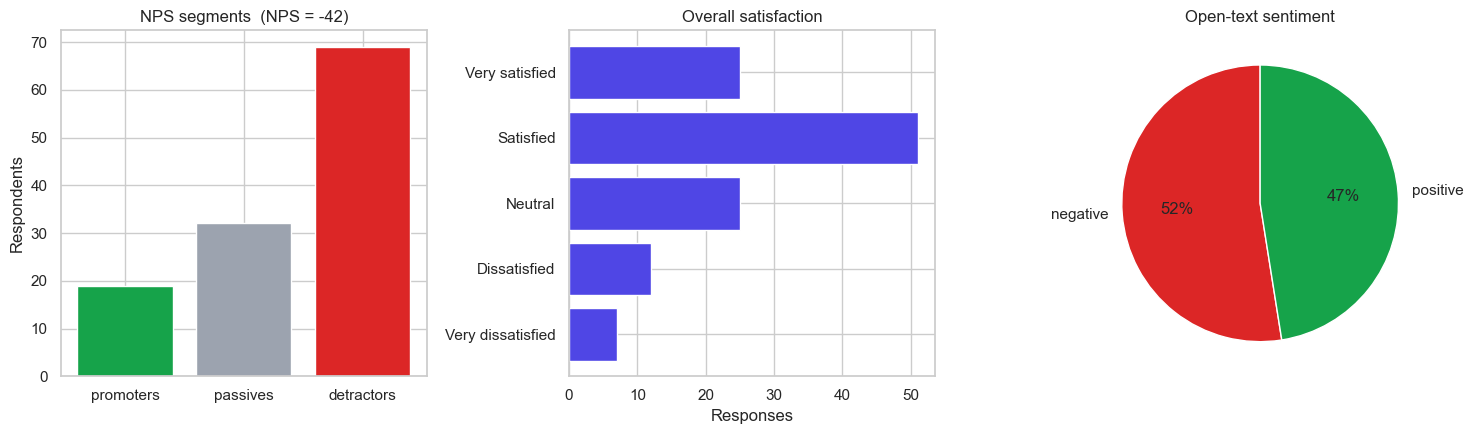

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# NPS segments
seg = pd.Series(breakdown)
axes[0].bar(seg.index, seg.values, color=['#16A34A', '#9CA3AF', '#DC2626'])
axes[0].set_title(f'NPS segments  (NPS = {nps:.0f})')
axes[0].set_ylabel('Respondents')

# Satisfaction (Likert) distribution
order = ['Very dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very satisfied']
sat_s = pd.Series(sat['distribution']).reindex(order).fillna(0)
axes[1].barh(sat_s.index, sat_s.values, color='#4F46E5')
axes[1].set_title('Overall satisfaction')
axes[1].set_xlabel('Responses')

# Open-text sentiment
sent = pd.Series(ot['sentiment'])
colors = {'positive': '#16A34A', 'neutral': '#9CA3AF', 'negative': '#DC2626'}
axes[2].pie(sent.values, labels=sent.index,
            colors=[colors.get(k, '#888') for k in sent.index],
            autopct='%1.0f%%', startangle=90)
axes[2].set_title('Open-text sentiment')

plt.tight_layout()
plt.savefig('survey.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Question | Type | Headline |
|----------|------|----------|
| Recommend (0-10) | NPS | NPS score + promoter/detractor split |
| Overall satisfaction | Likert | Mean 1-5 score + distribution |
| Current plan | Single-choice | Top category + counts |
| Hours per week | Numeric | mean / median / min / max |
| What can we improve? | Open-text | Sentiment % + themes |

A full-day manual survey workup collapses into one function call.

## 🔧 Try your own

Uncomment and point it at your own CSV:

In [8]:
# import pandas as pd
# my_df = pd.read_csv('your_survey.csv')
# my_report = analyze_survey(my_df)
# print('NPS:', my_report.nps)
# for q in my_report.questions:
#     print(q.column, '->', q.qtype)

---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — Day 24 of the 60-day FDE portfolio.

**Run the Streamlit version:**
```bash
pip install -r requirements.txt
streamlit run app.py
```